## Example of fitting a large model on GPU
Modern data collection methods mean that the number of single units obtained on a single session can easily approach many hundreds to thousands. Coupled with increasingly large design matrices, fitting Poisson GLMs to spiking data becomes extremely time consuming. Here we demonstrate fast fitting of a Poisson GLM with L2 regularization on the GPU.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
np.random.seed(42)

In [15]:
# simulate a reasonably sized dataset for modern neuropixels recordings
n_timepoints = 300_000
n_units = 400
n_regressors = 700

X, Y = make_regression(n_samples=n_timepoints, n_features=n_regressors, n_targets=n_units, noise=0.01, n_informative=500, random_state=42)
Y = np.random.poisson(lam=np.exp(Y / 1000)) # convert to spike counts

### Benchmark DAMN vs sklearn PoissonRegressor for fitting a Poisson GLM to spiking data

In [22]:
from damn.fit import fit_poisson_glm_adam, fit_poisson_glm_lbfgs
from sklearn.linear_model import PoissonRegressor
from sklearn.multioutput import MultiOutputRegressor
import time

target_unit_inds = np.arange(50) # only fitting to a subset of units for sake of speed, grab more units to see much greater speedup over sklearn

# --- sklearn ---
print('Fitting Poisson GLM with sklearn...')
tsk_start = time.perf_counter()

sklearn_model = MultiOutputRegressor(
    PoissonRegressor(alpha=0, max_iter=1000)
).fit(X, Y[:, target_unit_inds])

tsk = time.perf_counter()

Wsklearn = np.stack([estimator.coef_ for estimator in sklearn_model.estimators_]).T
bsklearn = np.stack([estimator.intercept_ for estimator in sklearn_model.estimators_])

# --- DAMN ---
print('\nFitting Poisson GLM with DAMN...\n')
tdamn_start = time.perf_counter()

Wdamn, bdamn = fit_poisson_glm_lbfgs(
    X, Y[:, target_unit_inds],
    alpha=0,
    early_stopping='train',
    max_epochs=1000
)[0:2]

tdamn = time.perf_counter()
print(f"sklearn time: {tsk - tsk_start:.4f} seconds")
print(f"DAMN time: {tdamn - tdamn_start:.4f} seconds")

print(f'\n\nSpeedup over sklearn is {((tsk - tsk_start) / (tdamn - tdamn_start)):.2f}x')

Fitting Poisson GLM with sklearn...

Fitting Poisson GLM with DAMN...

Removing 0 bad columns with all zeros, all nans, or all the same value
Epoch    0 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    1 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    2 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    3 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    4 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    5 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    6 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    7 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    8 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch    9 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch   10 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Epoch   11 | Train Loss: -1.58143e+00 | Train BPS: 1.21883
Early stopping triggered at epoch 11. No improvement greater than 1e-08 for 10 consecutive epochs.
sklearn time: 55.5246 seconds
DAMN time: 2.8280 sec

In [23]:
# evaluate the scores of these two models
from damn.scoring import bits_per_spike, bits_per_spike_multi_target

sklearn_bps = bits_per_spike(Y[:, target_unit_inds], sklearn_model.predict(X))
damn_bps = bits_per_spike(Y[:, target_unit_inds], np.exp(X @ Wdamn + bdamn))
print(f'\nsklearn bits per spike: {sklearn_bps:.4f}')
print(f'DAMN bits per spike: {damn_bps:.4f}')

#all_sklearn_bps = bits_per_spike_multi_target(Y[:, target_unit_inds], sklearn_model.predict(X))
#all_damn_bps = bits_per_spike_multi_target(Y[:, target_unit_inds], np.exp(X @ Wdamn + bdamn))

#plt.hist(all_sklearn_bps, alpha=0.5, label='sklearn')
#plt.hist(all_damn_bps, alpha=0.5, label='DAMN')
#plt.show()


sklearn bits per spike: 1.2199
DAMN bits per spike: 1.2199


### Automated optimal alpha selection
To avoid overfitting, it is usually best to apply some sort of weight penaly. We have included an L2 penalty by default, as well as a function to find the optimal alpha value. 




--- Trying alpha = 1e-12 ---
Removing 0 bad columns with all zeros, all nans, or all the same value
Epoch    0 | Train Loss: -1.68814e+00 | Train BPS: 1.25692 | Val Loss: -1.47730e+00 | Val BPS: 1.18564
Epoch    1 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    2 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    3 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    4 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    5 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    6 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    7 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.47784e+00 | Val BPS: 1.18598
Epoch    8 | Train Loss: -1.68950e+00 | Train BPS: 1.25776 | Val Loss: -1.4

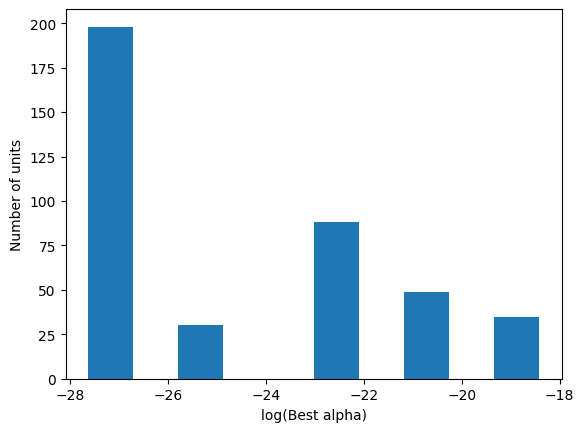

In [18]:
# Fit to the full dataset 
from damn.fit import fit_poisson_glm_best_alpha_per_target # different alpha for each target unit
from damn.fit import fit_poisson_glm_best_alpha # one alpha for the whole population

alpha_grid = np.logspace(-12, -8, 5) # try these out, the following function will warn you if you should expand the grid
best_W, best_b, best_alpha, history = fit_poisson_glm_best_alpha_per_target(X, Y,
                                                                            warm_start=True,
                                                                            val_fraction=.05,
                                                                            alpha_grid=alpha_grid)
plt.hist(np.log(best_alpha),)
plt.xlabel('log(Best alpha)')
plt.ylabel('Number of units')
plt.show()

# K-fold crossval

After the optimal alpha values are selected, we can perform the typical k-fold cross validation

In [19]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=False)

test_scores, train_scores = [], []
for i,(train_idx, test_idx) in enumerate(kf.split(X)):
    print(f'\n\nRunning fold {i+1}.....')
    X_train, Y_train = X[train_idx], Y[train_idx]
    X_test, Y_test = X[test_idx], Y[test_idx]

    W, b = fit_poisson_glm_lbfgs(X[train_idx],
                              Y[train_idx],
                              alpha=best_alpha,
                              max_epochs=2000,
                              val_fraction=0.1,
                              patience=10,
                              early_stopping='train',
                              print_every=1,
                              W_init=None, # warm start for speed, not necessary
                              b_init=None)[0:2]
    Yhat = np.exp(X_test @ W + b)
    fold_test_scores = bits_per_spike_multi_target(Y_test, Yhat)
    fold_train_scores = bits_per_spike_multi_target(Y_train, np.exp(X_train @ W + b))
    test_scores.append(fold_test_scores)
    train_scores.append(fold_train_scores)
test_scores = np.vstack(test_scores)
train_scores = np.vstack(train_scores)



Running fold 1.....
Removing 0 bad columns with all zeros, all nans, or all the same value
Epoch    0 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    1 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    2 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    3 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    4 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    5 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    6 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    7 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00 | Val BPS: 1.19000
Epoch    8 | Train Loss: -1.57518e+00 | Train BPS: 1.21621 | Val Loss: -1.48634e+00

Text(0, 0.5, 'Median Test Bits per Spike')

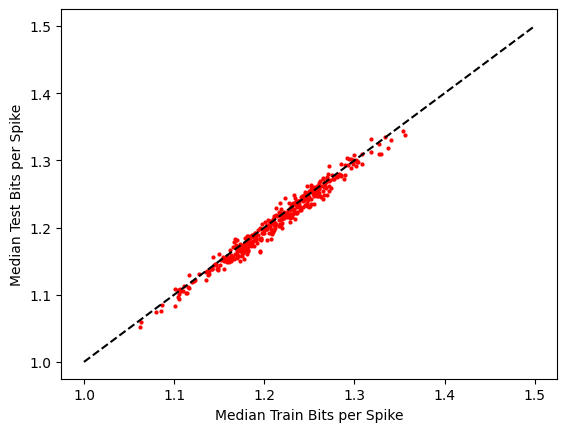

In [20]:
median_trains = np.median(train_scores, axis=0)
median_tests = np.median(test_scores, axis=0)

plt.plot(median_trains, median_tests, 'o', color='red', markersize=2)
plt.plot([1, 1.5], [1, 1.5], '--', color='black')
plt.xlabel('Median Train Bits per Spike')
plt.ylabel('Median Test Bits per Spike')